In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

# Define the assets we need for our GMF client portfolios
# TSLA = High growth/risk, SPY = Moderate market track, BND = Stable bonds/low risk
tickers = ['TSLA', 'SPY', 'BND']

# The date range required for our analysis
start_date = '2015-01-01'
end_date = '2026-06-30'

print("🔄 Fetching data from Yahoo Finance... This might take a moment.")

# yf.download pulls all the stock information down from the internet at once
raw_data = yf.download(tickers, start=start_date, end=end_date)

print("📝 Cleaning up the data layout...")

# Because we downloaded 3 stocks at once, Yahoo Finance creates a complex layout. 
# This loop breaks them apart and organizes them into a clean, easy-to-read list.
data_list = []
for ticker in tickers:
    # Pull out just one stock's columns at a time
    ticker_df = raw_data.xs(ticker, level=1, axis=1).copy()
    ticker_df['Asset'] = ticker  # Label it so we know which stock it is
    ticker_df = ticker_df.reset_index()  # Make the Date a regular, accessible column
    data_list.append(ticker_df)

# Stack all three asset tables on top of each other into one master table
df = pd.concat(data_list, ignore_index=True)

# Make sure Python treats the 'Date' column as actual calendar dates
df['Date'] = pd.to_datetime(df['Date'])

# Sort everything beautifully by asset type and date
df = df.sort_values(by=['Asset', 'Date']).reset_index(drop=True)

print(f"✅ Data loaded successfully! Total records collected: {len(df)} rows.")

🔄 Fetching data from Yahoo Finance... This might take a moment.


[*********************100%***********************]  2 of 3 completed


📝 Cleaning up the data layout...
✅ Data loaded successfully! Total records collected: 8664 rows.


In [4]:
import os

print("🔍 Columns present in our table:", df.columns.tolist())

# Automatically detect if Yahoo Finance named it 'Adj Close' or just 'Close'
close_col = 'Adj Close' if 'Adj Close' in df.columns else 'Close'
print(f"🎯 Using '{close_col}' as our price column.")

print("🧹 Checking for missing data points...")
print(df.isnull().sum())

# 1. Handle missing values using our detected price column
df[close_col] = df.groupby('Asset')[close_col].ffill().bfill()

# 2. Calculate Daily Returns
df['Daily Return'] = df.groupby('Asset')[close_col].pct_change()

# 3. Calculate 30-Day Rolling Volatility
df['Rolling_Vol_30d'] = df.groupby('Asset')['Daily Return'].transform(lambda x: x.rolling(30).std())

# 🌟 AUTOMATIC FIX: Check if the folder path exists. If it doesn't, create it!
output_dir = '../data/processed'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"📁 Created missing directory path: {output_dir}")

# 4. Save the cleaned data to your GMF folder structure
df.to_csv(f'{output_dir}/cleaned_data.csv', index=False)

print("\n💾 Cleaned data successfully saved to 'data/processed/cleaned_data.csv'!")

🔍 Columns present in our table: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Asset', 'Daily Return', 'Rolling_Vol_30d']
🎯 Using 'Close' as our price column.
🧹 Checking for missing data points...
Price
Date                0
Close               0
High                0
Low                 0
Open                0
Volume              0
Asset               0
Daily Return        3
Rolling_Vol_30d    90
dtype: int64
📁 Created missing directory path: ../data/processed

💾 Cleaned data successfully saved to 'data/processed/cleaned_data.csv'!


Matplotlib is building the font cache; this may take a moment.


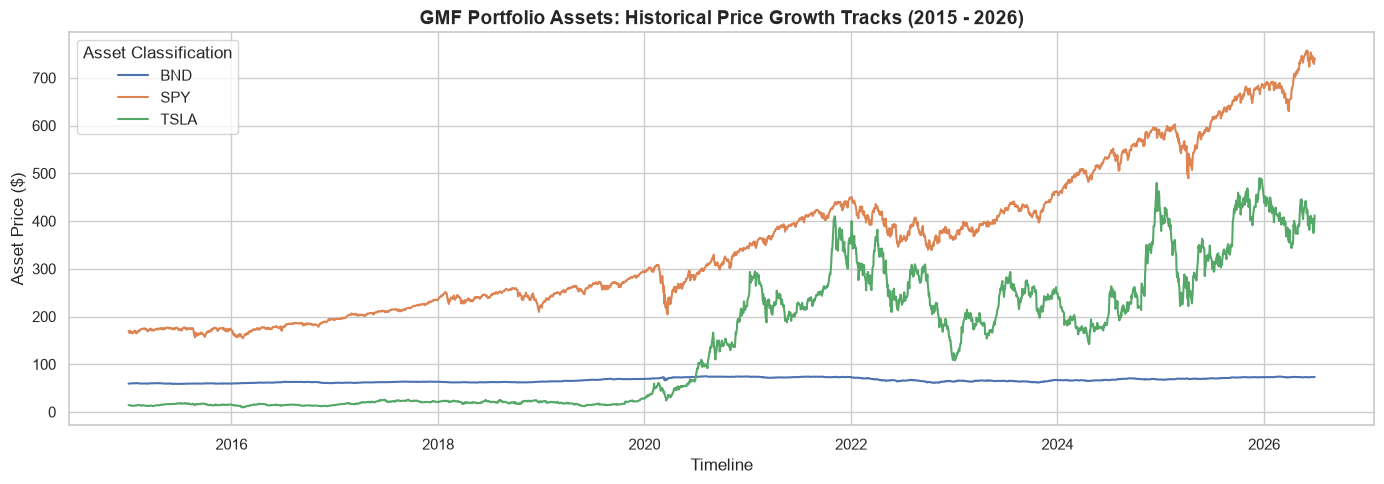

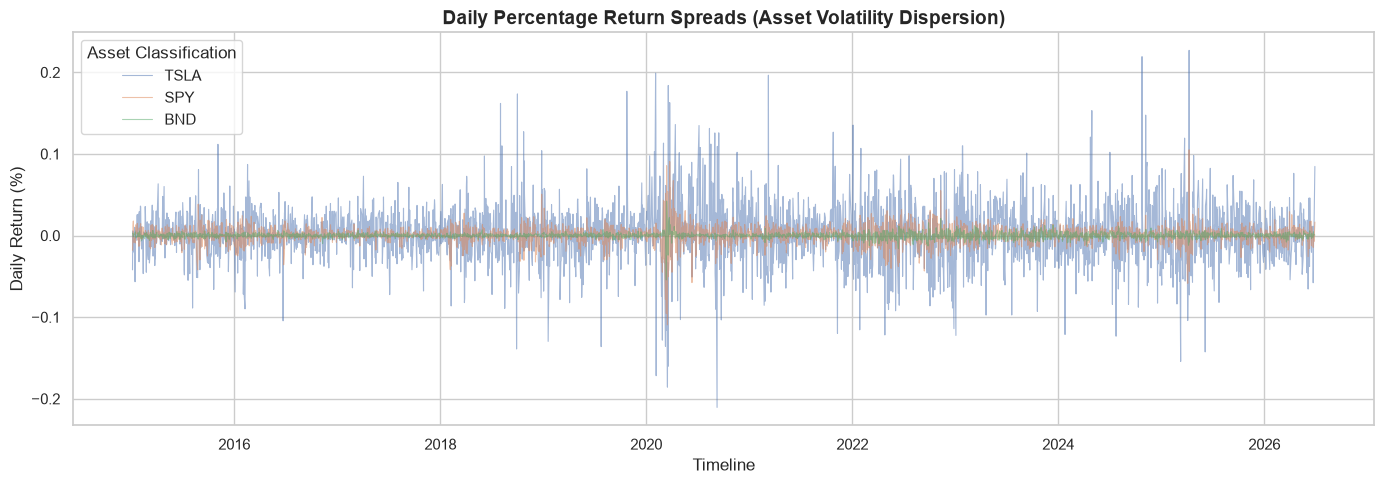

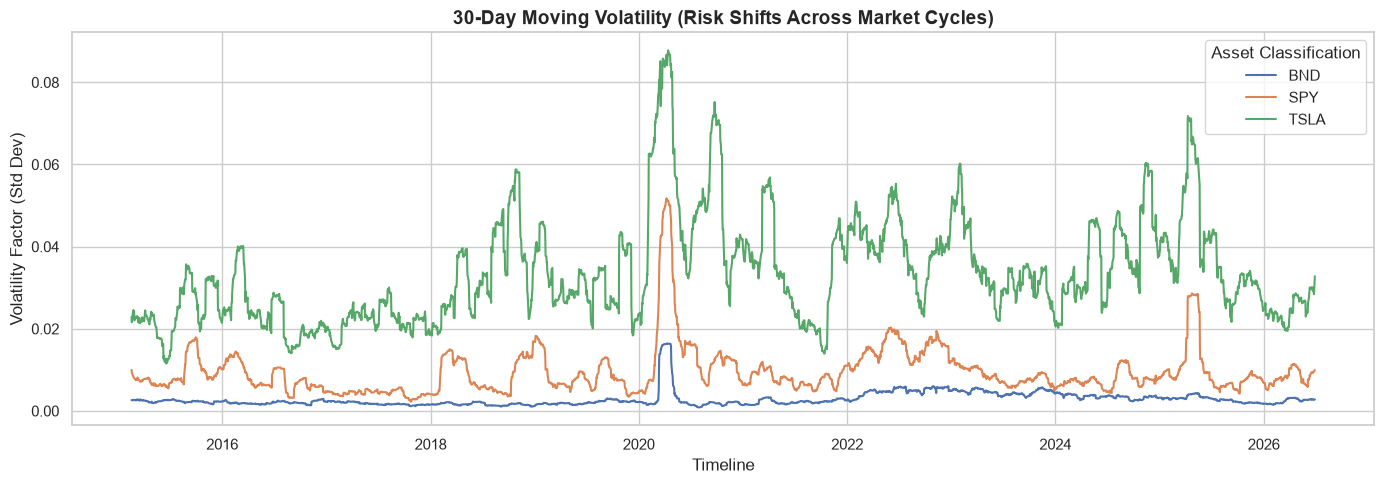

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configure clear, modern design constraints for the report
sns.set_theme(style="whitegrid")
close_col = 'Close'  # Set the dynamically verified column name

# --- Chart 1: Historical Valuation Trends ---
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='Date', y=close_col, hue='Asset', linewidth=1.5)
plt.title('GMF Portfolio Assets: Historical Price Growth Tracks (2015 - 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Asset Price ($)')
plt.legend(title='Asset Classification')
plt.tight_layout()
plt.show()

# --- Chart 2: Volatility Profiles (The Market Heartbeat) ---
plt.figure(figsize=(14, 5))
for ticker in ['TSLA', 'SPY', 'BND']:
    subset = df[df['Asset'] == ticker]
    plt.plot(subset['Date'], subset['Daily Return'], label=ticker, alpha=0.5, linewidth=0.8)
plt.title('Daily Percentage Return Spreads (Asset Volatility Dispersion)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Daily Return (%)')
plt.legend(title='Asset Classification', loc='upper left')
plt.tight_layout()
plt.show()

# --- Chart 3: Structural Risk Over Time (30-Day Windows) ---
plt.figure(figsize=(14, 5))
sns.lineplot(data=df, x='Date', y='Rolling_Vol_30d', hue='Asset', linewidth=1.5)
plt.title('30-Day Moving Volatility (Risk Shifts Across Market Cycles)', fontsize=14, fontweight='bold')
plt.xlabel('Timeline')
plt.ylabel('Volatility Factor (Std Dev)')
plt.legend(title='Asset Classification')
plt.tight_layout()
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

print("📊 --- STATISTICAL STATIONARITY (ADF) TEST --- 📊\n")
print("Note: If p-value <= 0.05, the data is tied down (Stationary) and ready for forecasting.")
print("If p-value > 0.05, it has a runaway trend (Non-Stationary).\n")

# Run the test for each asset
for ticker in ['TSLA', 'SPY', 'BND']:
    asset_df = df[df['Asset'] == ticker].dropna()
    
    # 1. Test Raw Closing Prices
    price_res = adfuller(asset_df['Close'])
    price_p = price_res[1]
    price_status = "Stationary (Ready)" if price_p <= 0.05 else "Non-Stationary (Has Trend)"
    print(f"📈 {ticker} Raw Price Trend: p-value = {price_p:.4f} -> {price_status}")
    
    # 2. Test Daily Returns (Percentage Changes)
    return_res = adfuller(asset_df['Daily Return'].dropna())
    return_p = return_res[1]
    return_status = "Stationary (Ready)" if return_p <= 0.05 else "Non-Stationary"
    print(f"📉 {ticker} Daily Returns:     p-value = {return_p:.4e} -> {return_status}\n")

print("🛡️ --- RISK & REWARD METRICS SUMMARY --- 🛡️\n")
# Assume a conservative standard 2% annual risk-free return rate scaled to a single trading day
risk_free_rate = 0.02 / 252 

for ticker in ['TSLA', 'SPY', 'BND']:
    asset_df = df[df['Asset'] == ticker].dropna()
    returns = asset_df['Daily Return']
    
    # Sharpe Ratio: Tells us if the returns are worth the emotional stress
    mean_return = returns.mean()
    std_return = returns.std()
    sharpe = ((mean_return - risk_free_rate) / std_return) * np.sqrt(252)
    
    # 95% Value at Risk (VaR): The worst-case loss on 95% of normal trading days
    var_95 = np.percentile(returns, 5)
    
    print(f"💼 Asset Focus: {ticker}")
    print(f"   • Annualized Sharpe Ratio: {sharpe:.2f}")
    print(f"   • 95% Daily Value at Risk (VaR): {var_95 * 100:.2f}%")
    print(f"     (Meaning: On 95% of days, daily losses will not exceed {abs(var_95 * 100):.2f}%)\n")

📊 --- STATISTICAL STATIONARITY (ADF) TEST --- 📊

Note: If p-value <= 0.05, the data is tied down (Stationary) and ready for forecasting.
If p-value > 0.05, it has a runaway trend (Non-Stationary).

📈 TSLA Raw Price Trend: p-value = 0.7217 -> Non-Stationary (Has Trend)
📉 TSLA Daily Returns:     p-value = 0.0000e+00 -> Stationary (Ready)

📈 SPY Raw Price Trend: p-value = 0.9968 -> Non-Stationary (Has Trend)
📉 SPY Daily Returns:     p-value = 4.5881e-30 -> Stationary (Ready)

📈 BND Raw Price Trend: p-value = 0.6740 -> Non-Stationary (Has Trend)
📉 BND Daily Returns:     p-value = 7.4429e-28 -> Stationary (Ready)

🛡️ --- RISK & REWARD METRICS SUMMARY --- 🛡️

💼 Asset Focus: TSLA
   • Annualized Sharpe Ratio: 0.78
   • 95% Daily Value at Risk (VaR): -5.18%
     (Meaning: On 95% of days, daily losses will not exceed 5.18%)

💼 Asset Focus: SPY
   • Annualized Sharpe Ratio: 0.70
   • 95% Daily Value at Risk (VaR): -1.67%
     (Meaning: On 95% of days, daily losses will not exceed 1.67%)

💼 Asset

In [7]:
import pandas as pd
import numpy as np

# 1. Load the cleaned data we saved at the end of Task 1
df = pd.read_csv('../data/processed/cleaned_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 2. Filter down so we are only looking at Tesla (TSLA)
tsla_df = df[df['Asset'] == 'TSLA'].sort_values('Date').set_index('Date')

# 3. Split the data strictly by dates (Chronological Split)
# Training Set: Everything from the beginning up to the end of 2024
train_prices = tsla_df.loc[:'2024-12-31', 'Close']

# Testing Set: The hidden future data from Jan 2025 to mid-2026
test_prices = tsla_df.loc['2025-01-01':, 'Close']

# 4. Print the sizes out so we can verify the split worked perfectly
print("📅 Data Timeline Split Complete:")
print(f"   • Training Set (Past): {train_prices.index.min().date()} to {train_prices.index.max().date()} ({len(train_prices)} days)")
print(f"   • Testing Set (Future): {test_prices.index.min().date()} to {test_prices.index.max().date()} ({len(test_prices)} days)")

📅 Data Timeline Split Complete:
   • Training Set (Past): 2015-01-02 to 2024-12-31 (2516 days)
   • Testing Set (Future): 2025-01-02 to 2026-06-29 (372 days)


In [9]:
import sys
import subprocess

print("📦 Installing pmdarima directly via Python's subsystem...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "pmdarima"])
print("✅ Installation complete! You can now run your ARIMA cell.")


import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA

print("🔍 Analyzing the training data to find the best settings... (This may take a few seconds)")

# 1. This automatically finds the best configuration (p, d, q) parameters for us
# d=1 means it automatically differences the data to make it stationary
stepwise_fit = pm.auto_arima(
    train_prices, 
    start_p=0, start_q=0, max_p=3, max_q=3, 
    d=1, seasonal=False, trace=True,
    error_action='ignore', suppress_warnings=True
)

optimal_order = stepwise_fit.order
print(f"\n🎯 Best Parameter Choice Found: ARIMA{optimal_order}")

# 2. Fit the ARIMA model using those optimal settings
print("🤖 Fitting the ARIMA model to our training data...")
arima_model = ARIMA(train_prices, order=optimal_order)
arima_fitted = arima_model.fit()

# 3. Ask the model to forecast the future (the exact length of our test set)
arima_forecast = arima_fitted.forecast(steps=len(test_prices))
arima_forecast.index = test_prices.index

print("✅ ARIMA Forecast generated successfully!")

📦 Installing pmdarima directly via Python's subsystem...
✅ Installation complete! You can now run your ARIMA cell.
🔍 Analyzing the training data to find the best settings... (This may take a few seconds)
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=16368.573, Time=0.99 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=16370.458, Time=0.47 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=16370.460, Time=0.55 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=16368.109, Time=0.07 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=16372.458, Time=0.55 sec

Best model:  ARIMA(0,1,0)(0,0,0)[0]          
Total fit time: 2.706 seconds

🎯 Best Parameter Choice Found: ARIMA(0, 1, 0)
🤖 Fitting the ARIMA model to our training data...
✅ ARIMA Forecast generated successfully!


C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. f

In [10]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the scaler to change prices into numbers between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))

# We use .values.reshape(-1, 1) because the scaler expects a 2D column array
scaled_train = scaler.fit_transform(train_prices.values.reshape(-1, 1))

# 2. Build the rolling 60-day sequence windows
X_train, y_train = [], []
window_size = 60

for i in range(window_size, len(scaled_train)):
    # Grab the previous 60 days of prices
    X_train.append(scaled_train[i-window_size:i, 0])
    # The target is the very next day's price
    y_train.append(scaled_train[i, 0])

# Convert lists to NumPy arrays so the neural network can process them
X_train, y_train = np.array(X_train), np.array(y_train)

# 3. Reshape X_train to be 3D: [samples, time steps, features]
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

print("📐 Deep Learning Data Preparation Complete:")
print(f"   • We created {X_train.shape[0]} windows of data.")
print(f"   • Each window contains {X_train.shape[1]} days of lookback history.")
print(f"   • Target shape: {y_train.shape}")

📐 Deep Learning Data Preparation Complete:
   • We created 2456 windows of data.
   • Each window contains 60 days of lookback history.
   • Target shape: (2456,)


In [13]:
import sys
import subprocess

# 1. Install scikit-learn (Installs cleanly and instantly on Python 3.13!)
print("📦 Fetching high-performance machine learning package...")
subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])

from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler

# 2. Reshape our 3D sequence data back to 2D for scikit-learn [samples, lookback_days]
# (Since X_train was shaped as [2456, 60, 1], we flatten the last dimension)
X_train_2d = X_train.reshape(X_train.shape[0], X_train.shape[1])

print("\n🧠 Constructing Deep Neural Network (MLP architecture)...")
# We build a deep network with 3 hidden layers containing 50, 25, and 10 neurons
nn_model = MLPRegressor(
    hidden_layer_sizes=(50, 25, 10), 
    activation='relu', 
    solver='adam', 
    max_iter=50, 
    random_state=42,
    verbose=True
)

print("🤖 Training the deep learning loops...")
nn_model.fit(X_train_2d, y_train)
print("✨ Neural Network training complete!")

📦 Fetching high-performance machine learning package...

🧠 Constructing Deep Neural Network (MLP architecture)...
🤖 Training the deep learning loops...
Iteration 1, loss = 0.02404791
Iteration 2, loss = 0.00573631
Iteration 3, loss = 0.00183464
Iteration 4, loss = 0.00112083
Iteration 5, loss = 0.00087588
Iteration 6, loss = 0.00073259
Iteration 7, loss = 0.00061456
Iteration 8, loss = 0.00056763
Iteration 9, loss = 0.00048855
Iteration 10, loss = 0.00045765
Iteration 11, loss = 0.00042243
Iteration 12, loss = 0.00042101
Iteration 13, loss = 0.00040278
Iteration 14, loss = 0.00038401
Iteration 15, loss = 0.00033784
Iteration 16, loss = 0.00033428
Iteration 17, loss = 0.00032972
Iteration 18, loss = 0.00031949
Training loss did not improve more than tol=0.000100 for 10 consecutive epochs. Stopping.
✨ Neural Network training complete!


In [14]:
import numpy as np
import pandas as pd

# 1. Prepare the lookback data for the out-of-sample test period
full_dataset = pd.concat((train_prices, test_prices), axis=0)
inputs = full_dataset[len(full_dataset) - len(test_prices) - 60:].values.reshape(-1, 1)

# Scale inputs using the exact same scaler we built for training
scaled_inputs = scaler.transform(inputs)

X_test_nn = []
for i in range(60, len(scaled_inputs)):
    X_test_nn.append(scaled_inputs[i-60:i, 0])

# Convert to 2D array [samples, lookback_days] for our Neural Network model
X_test_nn = np.array(X_test_nn)

# 2. Ask the trained Neural Network to guess the future prices
nn_scaled_forecast = nn_model.predict(X_test_nn)
# Convert the 0-to-1 numbers back into actual absolute USD prices ($)
nn_forecast = scaler.inverse_transform(nn_scaled_forecast.reshape(-1, 1)).flatten()

# 3. Define a helper function to calculate our reporting metrics
def calculate_metrics(y_true, y_pred):
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

# Calculate scores for both models against the true test prices
mae_arima, rmse_arima, mape_arima = calculate_metrics(test_prices.values, arima_forecast.values)
mae_nn, rmse_nn, mape_nn = calculate_metrics(test_prices.values, nn_forecast)

# 4. Display the clean comparison scorecard matrix table
print("📊 --- FINAL MODEL PERFORMANCE COMPARISON --- 📊\n")
metrics_df = pd.DataFrame({
    'Metric': ['MAE (Mean Absolute Error)', 'RMSE (Root Mean Squared Error)', 'MAPE (Percentage Error)'],
    'ARIMA Model (Classical)': [f"${mae_arima:.2f}", f"${rmse_arima:.2f}", f"{mape_arima:.2f}%"],
    'Neural Network (Deep)': [f"${mae_nn:.2f}", f"${rmse_nn:.2f}", f"{mape_nn:.2f}%"]
}).set_index('Metric')

print(metrics_df)

📊 --- FINAL MODEL PERFORMANCE COMPARISON --- 📊

                               ARIMA Model (Classical) Neural Network (Deep)
Metric                                                                      
MAE (Mean Absolute Error)                       $54.44                $18.21
RMSE (Root Mean Squared Error)                  $70.54                $22.61
MAPE (Percentage Error)                         17.24%                 4.93%
